# Nusselt number prediction — 2D Rayleigh-Bénard convection

Following Sec. 3.3 ("Forecasting heat transport using machine learning") of
Shreshthi & Pandey, *Turbulent Prandtl number in the near-wall region of
thermal convection*. See `references.md` for where every data point comes from.

Input: `Pr`, `Ra`. Output: `Nu`. Model: random forest regression, 70/30
train-test split, R² on the test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

df = pd.read_csv("../data/nu_dataset_model.csv")
print(f"{len(df)} data points")
df.head()

59 data points


,Pr,Ra,Nu
0,0.021,1000000000,37.43
1,0.050,1000000000,41.51
2,0.100,1000000000,42.72
3,0.200,1000000000,45.98
4,0.350,1000000000,48.10


## 1. Look at the data first

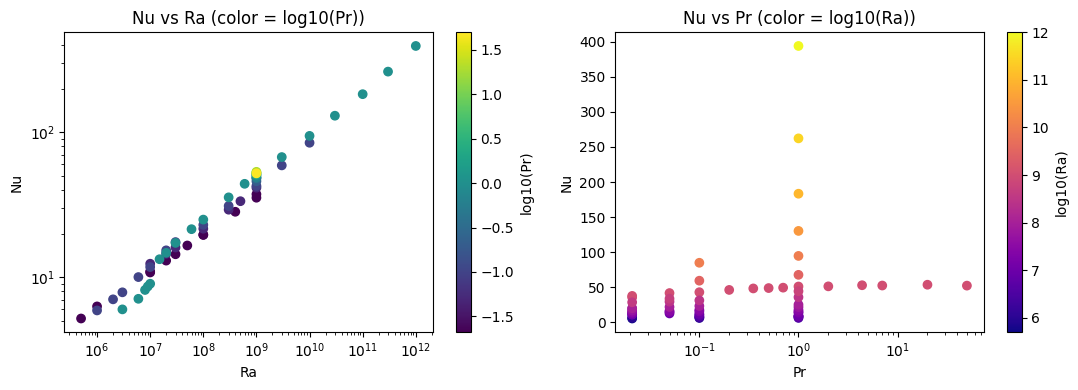

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sc = axes[0].scatter(df["Ra"], df["Nu"], c=np.log10(df["Pr"]), cmap="viridis")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Ra")
axes[0].set_ylabel("Nu")
axes[0].set_title("Nu vs Ra (color = log10(Pr))")
plt.colorbar(sc, ax=axes[0], label="log10(Pr)")

sc2 = axes[1].scatter(df["Pr"], df["Nu"], c=np.log10(df["Ra"]), cmap="plasma")
axes[1].set_xscale("log")
axes[1].set_xlabel("Pr")
axes[1].set_ylabel("Nu")
axes[1].set_title("Nu vs Pr (color = log10(Ra))")
plt.colorbar(sc2, ax=axes[1], label="log10(Ra)")

plt.tight_layout()
plt.savefig("../results/eda_scatter.png", dpi=150)
plt.show()

## 2. Train/test split and random forest

Same recipe as the paper: inputs are `Pr` and `Ra` (log10-transformed, matching
Figure 4's axes), 70/30 split, 5 trees.

In [3]:
X = np.log10(df[["Pr", "Ra"]])
y = df["Nu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(n_estimators=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 on test set: {r2:.3f}")

R^2 on test set: 0.971


## 3. Predicted vs. actual (compare to Figure 4 in the paper)

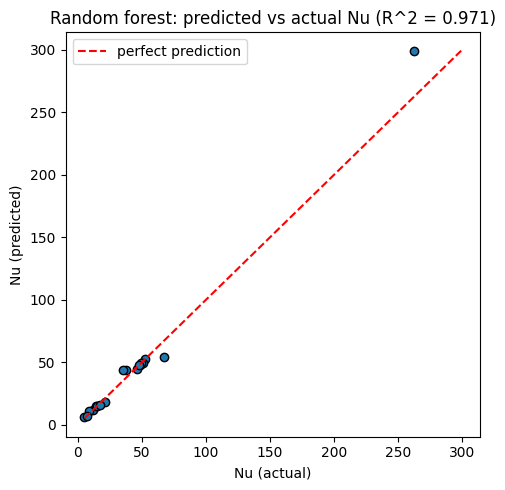

In [4]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Nu (actual)")
plt.ylabel("Nu (predicted)")
plt.title(f"Random forest: predicted vs actual Nu (R^2 = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("../results/predicted_vs_actual.png", dpi=150)
plt.show()

## 4. Sensitivity checks

The paper notes R² doesn't change much for 5 to 100 trees, and reports it's
hard to get a reliable Reynolds-number model from a small dataset. Worth
checking both as you extend this.

In [5]:
for n_trees in [5, 10, 25, 50, 100]:
    m = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    m.fit(X_train, y_train)
    score = r2_score(y_test, m.predict(X_test))
    print(f"n_estimators={n_trees:>3}  R^2={score:.3f}")

n_estimators=  5  R^2=0.971
n_estimators= 10  R^2=0.984
n_estimators= 25  R^2=0.960
n_estimators= 50  R^2=0.963
n_estimators=100  R^2=0.952


## Notes / open items

- Before trusting these numbers: check `../data/nu_dataset.csv`'s Notes
  column for rows flagged as likely duplicates (same simulation reused
  across two papers) or a different configuration ("RBC-P"), and decide
  whether to drop them from `nu_dataset_model.csv`.
- van der Poel et al. (2013) and Zhang & Zhou (2024) are not yet included
  (see `references.md`) — re-run this notebook once those are added.
- The dataset is small (order ~50-70 points) and the test split is random,
  so R² will vary somewhat run to run if you change `random_state` — worth
  reporting a range, not a single number, once the dataset is final.